# Assignment 2: Transformer Architecture Excercise

Roger Kutyna
https://github.com/rkutyna/MSIT3103-GenAI-assignments/blob/main/assignment_2


In [1]:
# Imports for models, etc
# Taken from hotstart

import os
import torch
from datasets import load_dataset
from transformers import (
    AutoTokenizer,
    AutoModelForCausalLM,
    AutoModelForMaskedLM,
    AutoModelForSeq2SeqLM,
    DataCollatorForLanguageModeling,
    DataCollatorForSeq2Seq,
    Trainer,
    TrainingArguments,
)
import evaluate
from transformers import logging

# Silence warnings for cleaner output
logging.set_verbosity_error()

# Use GPU if available
device = torch.device("mps" if torch.mps.is_available() else "cpu")
print(f"Using device: {device}")

Using device: mps


#### Load Dataset:
Cell taken from hotstart

In [2]:
# Load the cnn_dailymail dataset (version 3.0.0)
dataset = load_dataset("cnn_dailymail", "3.0.0")

The CNN/DailyMail dataset was selected because it is ideal for training and testing model summarization. Given that summarization was one of the first widespread uses of tools like ChatGPT, this feels like a good test to understand the strengths and weaknesses of encoder/decoder transformer models.

#### Preprocessing:
Cell taken from hotstart

This code first sets the train_size and val_size. These parameters determine how much data is going to be used. In this case, the train_size is 500 articles and the validation size is set to 100 articles. As stated in the hotstart, this is a small subset of the dataset to allow for quicker training. I will use these values as variables to train the model to attempt to achieve better results.

After this, the GPT-2 model and tokenizer are loaded. 

The pre-processing is then done. This adds the prefix "summarize: " to the beginning of each article. This is part of the prompt to get GPT-2 to generate a summary of the article. Because this is supervised training, the highlights of the article are taken to be used as the labels that the generated summaries are compared to. 

In [3]:
# For quick experimentation, take a small subset
train_size = 500
val_size = 100
small_train_dataset = dataset["train"].shuffle(seed=42).select(range(train_size))
small_val_dataset = dataset["validation"].shuffle(seed=42).select(range(val_size))

print("Dataset splits:", dataset.keys())
print("Example training record:", small_train_dataset[0])

# Load tokenizer and model for GPT-2
gpt2_model_name = "gpt2"
gpt2_tokenizer = AutoTokenizer.from_pretrained(gpt2_model_name)

# Add a padding token (GPT-2 does not have one)
gpt2_tokenizer.pad_token = gpt2_tokenizer.eos_token

# Define the preprocessing function for GPT-2
def preprocess_gpt2(examples):
    prefix = "summarize: "
    inputs = [prefix + art for art in examples["article"]]
    targets = examples["highlights"]

    # Tokenize inputs and targets together, pad to max_length
    model_inputs = gpt2_tokenizer(
        inputs, text_target=targets,
        max_length=512, truncation=True, padding="max_length"
    )

    # Ensure labels are padded to max_length as well
    if "labels" in model_inputs:
        labels = model_inputs["labels"]
        for i in range(len(labels)):
            labels[i] = labels[i] + [-100] * (512 - len(labels[i])) if len(labels[i]) < 512 else labels[i][:512]
        model_inputs["labels"] = labels
    return model_inputs

# Apply preprocessing to the small datasets
train_gpt2 = small_train_dataset.map(preprocess_gpt2, batched=True, remove_columns=dataset["train"].column_names)
val_gpt2 = small_val_dataset.map(preprocess_gpt2, batched=True, remove_columns=dataset["validation"].column_names)

print("Sample tokenized GPT-2 input:")
print(gpt2_tokenizer.decode(train_gpt2[0]["input_ids"][:100]))

Dataset splits: dict_keys(['train', 'validation', 'test'])
Example training record: {'article': "By . Anthony Bond . PUBLISHED: . 07:03 EST, 2 March 2013 . | . UPDATED: . 08:07 EST, 2 March 2013 . Three members of the same family who died in a static caravan from carbon monoxide poisoning would have been unconscious 'within minutes', investigators said today. The bodies of married couple John and Audrey Cook were discovered alongside their daughter, Maureen, at the mobile home they shared on Tremarle Home Park in Camborne, west Cornwall. The inquests have now opened into the deaths last Saturday, with investigators saying the three died along with the family's pet dog, of carbon monoxide poisoning from a cooker. Tragic: The inquests have opened into the deaths of three members of the same family who were found in their static caravan last weekend. John and Audrey Cook are pictured . Awful: The family died following carbon monoxide poisoning at this caravan at the Tremarle Home Park in 

In [4]:
print("Input IDs and Labels dimensions for first 10 samples:")
for i in range(10):
    print(f"Sample {i}: Input IDs length = {len(train_gpt2[i]['input_ids'])}, Labels length = {len(train_gpt2[i]['labels'])}")

Input IDs and Labels dimensions for first 10 samples:
Sample 0: Input IDs length = 512, Labels length = 512
Sample 1: Input IDs length = 512, Labels length = 512
Sample 2: Input IDs length = 512, Labels length = 512
Sample 3: Input IDs length = 512, Labels length = 512
Sample 4: Input IDs length = 512, Labels length = 512
Sample 5: Input IDs length = 512, Labels length = 512
Sample 6: Input IDs length = 512, Labels length = 512
Sample 7: Input IDs length = 512, Labels length = 512
Sample 8: Input IDs length = 512, Labels length = 512
Sample 9: Input IDs length = 512, Labels length = 512


In [4]:
# Needed to ensure that gpu acceleration on apple silicon works
import accelerate, transformers
print("accelerate:", accelerate.__version__)
print("transformers:", transformers.__version__)

accelerate: 1.10.1
transformers: 4.56.1


In [ ]:
# Define data collator
data_collator_gpt2 = DataCollatorForLanguageModeling(tokenizer=gpt2_tokenizer, mlm=False)

# Load the GPT-2 model
gpt2_model = AutoModelForCausalLM.from_pretrained(gpt2_model_name)

# Training arguments
training_args_gpt2 = TrainingArguments(
    output_dir="./gpt2-summarization",
    eval_strategy="steps",       
    eval_steps=100,
    logging_strategy="steps",          # ensure logs are emitted by steps
    logging_steps=1,                  # adjust as you like for smoother curves
    per_device_train_batch_size=2,
    per_device_eval_batch_size=2,
    num_train_epochs=3,
    weight_decay=0.01,
    save_steps=500,
    save_total_limit=1,
    warmup_steps=50,
    gradient_accumulation_steps=4,
    fp16=torch.cuda.is_available(),
    report_to=[],                      # keep W&B off
)

# Create Trainer for GPT-2
trainer_gpt2 = Trainer(
    model=gpt2_model,
    args=training_args_gpt2,
    train_dataset=train_gpt2,
    eval_dataset=val_gpt2,
    data_collator=data_collator_gpt2,
)

# Uncomment the line below to train; training can take several minutes even on small subsets
#trainer_gpt2.train()

/Users/rkutyna/CascadeProjects/MSIT3103/MSIT3103-GenAI-assignments/.venv/lib/python3.13/site-packages/torch/utils/data/dataloader.py:684: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pinned memory won't be used.
  warnings.warn(warn_msg)


{'loss': 3.6742, 'grad_norm': 6.298336029052734, 'learning_rate': 0.0, 'epoch': 0.016}
{'loss': 3.4603, 'grad_norm': 5.9394354820251465, 'learning_rate': 1.0000000000000002e-06, 'epoch': 0.032}
{'loss': 3.2621, 'grad_norm': 4.926506042480469, 'learning_rate': 2.0000000000000003e-06, 'epoch': 0.048}
{'loss': 3.3797, 'grad_norm': 5.253885746002197, 'learning_rate': 3e-06, 'epoch': 0.064}
{'loss': 3.5, 'grad_norm': 6.156080722808838, 'learning_rate': 4.000000000000001e-06, 'epoch': 0.08}
{'loss': 3.4011, 'grad_norm': 5.496487140655518, 'learning_rate': 5e-06, 'epoch': 0.096}
{'loss': 3.7067, 'grad_norm': 6.373993396759033, 'learning_rate': 6e-06, 'epoch': 0.112}
{'loss': 3.3818, 'grad_norm': 5.366942405700684, 'learning_rate': 7.000000000000001e-06, 'epoch': 0.128}
{'loss': 3.2882, 'grad_norm': 5.0644307136535645, 'learning_rate': 8.000000000000001e-06, 'epoch': 0.144}
{'loss': 3.2007, 'grad_norm': 4.775594711303711, 'learning_rate': 9e-06, 'epoch': 0.16}
{'loss': 3.4884, 'grad_norm': 5.4

TrainOutput(global_step=189, training_loss=3.0467444790734186, metrics={'train_runtime': 343.0848, 'train_samples_per_second': 4.372, 'train_steps_per_second': 0.551, 'train_loss': 3.0467444790734186, 'epoch': 3.0})

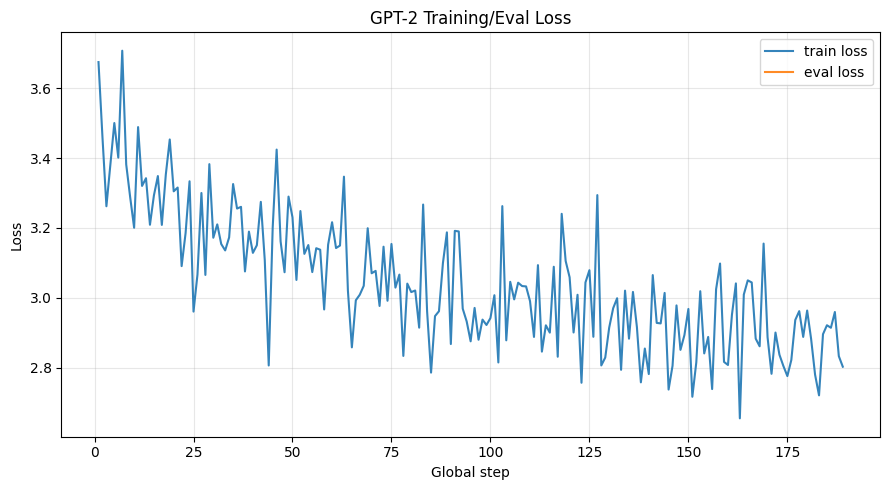

In [ ]:
# Generate by GPT-5 (high reasoning) via Windsurf 9/15/25
# Prompt: Can you please create a cell to plot the loss curve for training GPT-2

import matplotlib.pyplot as plt

# Extract logs collected during training
log_history = trainer_gpt2.state.log_history

# Training loss per logging step
train_points = [(e["step"], e["loss"]) for e in log_history if "loss" in e and "step" in e]
# Evaluation loss (if evaluation_strategy="steps")
eval_points  = [(e["step"], e["eval_loss"]) for e in log_history if "eval_loss" in e and "step" in e]

plt.figure(figsize=(9,5))
if train_points:
    steps, losses = zip(*train_points)
    plt.plot(steps, losses, label="train loss", alpha=0.9)
if eval_points:
    eval_steps, eval_losses = zip(*eval_points)
    plt.plot(eval_steps, eval_losses, label="eval loss", alpha=0.9)

plt.xlabel("Global step")
plt.ylabel("Loss")
plt.title("GPT-2 Training/Eval Loss")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# Evaluating GPT-2

In [ ]:
# Generated by GPT-5 (high reasoning)
# Prompt: Can you help me with this error? (ERROR with mps/apple silicon acceleration)

import torch

# Choose device
device = torch.device(
    "mps" if torch.backends.mps.is_available() else
    ("cuda" if torch.cuda.is_available() else "cpu")
)
print("Using device:", device)

# Ensure GPT-2 has a pad token and move model to device in float32
gpt2_tokenizer.pad_token = gpt2_tokenizer.eos_token
gpt2_model.config.pad_token_id = gpt2_tokenizer.pad_token_id

gpt2_model.to(device=device, dtype=torch.float32)
gpt2_model.eval()

sample_input = "summarize: The quick brown fox jumps over the lazy dog."
inputs = gpt2_tokenizer(sample_input, return_tensors="pt", padding=True).to(device)

# Warm-up pass to force allocation on MPS
with torch.no_grad():
    _ = gpt2_model(input_ids=inputs["input_ids"][:, :1], attention_mask=torch.ones_like(inputs["input_ids"][:, :1]))

# Generate (pass the whole dict so attention_mask is used)
with torch.no_grad():
    outputs = gpt2_model.generate(
        **inputs,
        max_length=100,
        num_return_sequences=1,
        do_sample=False,  # greedy; change if you want sampling
    )

print("Input: ", sample_input)
print(gpt2_tokenizer.decode(outputs[0], skip_special_tokens=True)[len(sample_input)+1:])



Using device: mps
Input:  summarize: The quick brown fox jumps over the lazy dog.
The dog is so happy to be home, but the fox is so scared of the dog that he jumps over the lazy dog. The dog is so happy to be home, but the fox is so scared of the dog that he jumps over the lazy dog. The dog is so happy to be home, but the fox is so scared of the dog that he jumps over the lazy dog. The dog is so happy to be home


As can be seen above, when being trained on a relatively small sample size, the model is not really able to summarize this text. A summary is supposed to be shorter, but instead the model writes a longer sentence and repeats it.

In [ ]:
# Code generated by GPT-5 (high reasoning) via Windsurf 9/15/25
# Prompt: Can you generate code to add to the bottom of this cell to test it on 
# the actual news articles? Preferable from the dataset['test'] subset, just 3 
# random articles+summaries would be perfect

# --- Test on 3 random CNN/DailyMail test samples ---
from datasets import load_dataset

# Load just the test split and pick 3 random samples
test_ds = load_dataset("cnn_dailymail", "3.0.0", split="test").select(range(3))

def gpt2_summarize_article(article: str) -> str:
    prompt = "summarize: " + article
    # Truncate long articles to fit in the GPT-2 context
    enc = gpt2_tokenizer(
        prompt,
        return_tensors="pt",
        truncation=True,
        max_length=512,
    ).to(device)

    with torch.no_grad():
        output_ids = gpt2_model.generate(
            **enc,
            max_new_tokens=128,            # number of new tokens to generate
            num_beams=4,                   # try beam search for more focused summaries
            no_repeat_ngram_size=3,        # reduce repetition
            length_penalty=1.0,
            early_stopping=True,
            pad_token_id=gpt2_tokenizer.pad_token_id,
            eos_token_id=gpt2_tokenizer.eos_token_id,
            do_sample=False,               # set True + top_p/top_k if you want sampling
            # top_p=0.9, top_k=50, temperature=0.9,  # uncomment if do_sample=True
        )

    # Slice off the prompt so we only decode newly generated tokens
    input_len = enc["input_ids"].shape[1]
    new_tokens = output_ids[0, input_len:]
    summary = gpt2_tokenizer.decode(new_tokens, skip_special_tokens=True).strip()
    return summary

for i, ex in enumerate(test_ds):
    article = ex["article"]
    reference = ex["highlights"]

    generated = gpt2_summarize_article(article)

    print(f"\n=== Sample #{i+1} ===")
    print("Article (truncated):", article[:400].replace("\n", " "), "...")
    print("\nReference summary:")
    print(reference)
    print("\nGPT-2 summary:")
    print(generated if generated else "[Empty generation]")
    print("=" * 80)


=== Sample #1 ===
Article (truncated): (CNN)The Palestinian Authority officially became the 123rd member of the International Criminal Court on Wednesday, a step that gives the court jurisdiction over alleged crimes in Palestinian territories. The formal accession was marked with a ceremony at The Hague, in the Netherlands, where the court is based. The Palestinians signed the ICC's founding Rome Statute in January, when they also acce ...

Reference summary:
Membership gives the ICC jurisdiction over alleged crimes committed in Palestinian territories since last June .
Israel and the United States opposed the move, which could open the door to war crimes investigations against Israelis .

GPT-2 summary:
. "The United States believes that the ICC is an important tool in the fight against terrorism, and we will continue to work closely with the Palestinian Authority to ensure that it does not join the court." Israel's Foreign Ministry said Wednesday that it was "deeply disappointed" by

It seems that, when told to summarize the article, GPT-2 tends to attempt to continue the article rather than summarize it. This make sense as GPT-2 is a relatively small model and is not trained on summarizing text, beyond the small amount of fine tuning that was done earlier in this file. It eventually begins to repeat itself while getting the details wrong. This model is able to string together plausible sentences, but has a hard time staying consistent accross longer periods of text. This is likely not helped by the truncation of the input text that leaves the article incomplete, likely confusing the model and increasing the change of simply continuing the article.

#### GPT-2 Evaluation

GPT-2 without any fine tuning

In [35]:
# Define ROUGE metric
from transformers.generation import beam_search


evaluate_rouge = evaluate.load("rouge")

def compute_metrics_rouge(preds, refs):
    # Compute ROUGE scores; use newline separation between sentences in each text
    result = evaluate_rouge.compute(predictions=preds, references=refs, use_stemmer=True)
    return {k: round(v * 100, 2) for k, v in result.items()}

# Function to generate summaries with GPT-2
def evaluate_gpt2(model, tokenizer, dataset, lp, nr, num_samples=10, nb=1):
    model.eval()
    preds, refs = [], []
    for i, example in enumerate(dataset.select(range(num_samples))):
        prompt = "summarize: " + example["article"]
        inputs = tokenizer(prompt, return_tensors="pt", truncation=True, max_length=512).to(model.device)
        with torch.no_grad():
            output_ids = model.generate(**inputs, 
            max_new_tokens=128, length_penalty=lp, 
            no_repeat_ngram_size=nr,
            do_sample=False,
            num_beams=nb,
            early_stopping=True)
        summary = tokenizer.decode(output_ids[0], skip_special_tokens=True)
        preds.append(summary)
        refs.append(example["highlights"])
    rouge_scores = compute_metrics_rouge(preds, refs)
    return rouge_scores

# Function to compute perplexity from evaluation loss
def compute_perplexity(eval_output):
    loss = eval_output["eval_loss"]
    return round(torch.exp(torch.tensor(loss)).item(), 3)

# Evaluate GPT-2 (if trained) -- example usage
gpt2_eval_results = trainer_gpt2.evaluate()
gpt2_perplexity = compute_perplexity(gpt2_eval_results)
rouge_gpt2 = evaluate_gpt2(gpt2_model, gpt2_tokenizer, small_val_dataset,lp=1, nr=1)
print("GPT-2 Perplexity:", gpt2_perplexity)
print("GPT-2 ROUGE:", rouge_gpt2)

{'eval_loss': 2.9442834854125977, 'eval_runtime': 8.5742, 'eval_samples_per_second': 11.663, 'eval_steps_per_second': 5.831, 'epoch': 3.0}
GPT-2 Perplexity: 18.997
GPT-2 ROUGE: {'rouge1': np.float64(16.72), 'rouge2': np.float64(8.24), 'rougeL': np.float64(11.36), 'rougeLsum': np.float64(13.76)}


#### GPT-2 fine tuning:

Testing impact of number of beams

In [38]:
gpt2_eval_results = trainer_gpt2.evaluate()
gpt2_perplexity = compute_perplexity(gpt2_eval_results)
print("GPT-2 Perplexity:", gpt2_perplexity)

for i in range(1, 6):
    print("Number of beams:", i )
    
    rouge_gpt2 = evaluate_gpt2(gpt2_model, gpt2_tokenizer, small_val_dataset, lp=1, nr=1, nb=i)
    
    print("GPT-2 ROUGE:", rouge_gpt2)


/Users/rkutyna/CascadeProjects/MSIT3103/MSIT3103-GenAI-assignments/.venv/lib/python3.13/site-packages/torch/utils/data/dataloader.py:684: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pinned memory won't be used.
  warnings.warn(warn_msg)


{'eval_loss': 2.9442834854125977, 'eval_runtime': 30.0693, 'eval_samples_per_second': 3.326, 'eval_steps_per_second': 1.663, 'epoch': 3.0}
GPT-2 Perplexity: 18.997
Number of beams: 1
GPT-2 ROUGE: {'rouge1': np.float64(16.72), 'rouge2': np.float64(8.24), 'rougeL': np.float64(11.36), 'rougeLsum': np.float64(13.76)}
Number of beams: 2
GPT-2 ROUGE: {'rouge1': np.float64(16.82), 'rouge2': np.float64(8.32), 'rougeL': np.float64(11.45), 'rougeLsum': np.float64(13.97)}
Number of beams: 3
GPT-2 ROUGE: {'rouge1': np.float64(16.59), 'rouge2': np.float64(8.31), 'rougeL': np.float64(11.42), 'rougeLsum': np.float64(13.89)}
Number of beams: 4
GPT-2 ROUGE: {'rouge1': np.float64(16.76), 'rouge2': np.float64(8.36), 'rougeL': np.float64(11.4), 'rougeLsum': np.float64(13.91)}
Number of beams: 5
GPT-2 ROUGE: {'rouge1': np.float64(16.7), 'rouge2': np.float64(8.23), 'rougeL': np.float64(11.34), 'rougeLsum': np.float64(13.7)}


Impact of num_beams:

As the number of beams goes up, the rouge 1, 2, L and Lsum increase. However, these increasea at a very slow rate compared to the rapidly sclin gincrease in time it takes for this generation to occur. It seems like the best result I got was with 2 beams with a very slightly higher rouge1, 2, L and Lsum compared to using 1 beam. This might be worth while pursuing with substantially more compute available, but at this scale, going above 2 beams does not seem worth it.

Length Penalty testing:

In [42]:
for i in range(10, 15):
    print("Length Penalty:", i/10)
    
    rouge_gpt2 = evaluate_gpt2(gpt2_model, gpt2_tokenizer, small_val_dataset, lp=i/10, nr=1, nb=2)
    
    print("GPT-2 ROUGE:", rouge_gpt2)

Length Penalty: 1.0
GPT-2 ROUGE: {'rouge1': np.float64(16.82), 'rouge2': np.float64(8.32), 'rougeL': np.float64(11.45), 'rougeLsum': np.float64(13.97)}
Length Penalty: 1.1
GPT-2 ROUGE: {'rouge1': np.float64(16.57), 'rouge2': np.float64(8.17), 'rougeL': np.float64(11.28), 'rougeLsum': np.float64(13.76)}
Length Penalty: 1.2
GPT-2 ROUGE: {'rouge1': np.float64(16.57), 'rouge2': np.float64(8.17), 'rougeL': np.float64(11.28), 'rougeLsum': np.float64(13.76)}
Length Penalty: 1.3
GPT-2 ROUGE: {'rouge1': np.float64(16.57), 'rouge2': np.float64(8.17), 'rougeL': np.float64(11.28), 'rougeLsum': np.float64(13.76)}
Length Penalty: 1.4
GPT-2 ROUGE: {'rouge1': np.float64(16.57), 'rouge2': np.float64(8.17), 'rougeL': np.float64(11.28), 'rougeLsum': np.float64(13.76)}


Impact of length penalty

It seems to me that the length penalty had little impact, only decreasing all rouge scores slightly. Penalties above 1.1 did not seem to have an impact. This is likely due to the max new tokens being set to 128, so the model is likely being cut off. The number of beams is also only 2, so this may not be enough to enable the length penalty to have much affect.

No Repeat ngram testing:

In [43]:
for i in range(1, 5):
    print("No repeat ngram:", i)
    
    rouge_gpt2 = evaluate_gpt2(gpt2_model, gpt2_tokenizer, small_val_dataset, lp=1, nr=i, nb=2)
    
    print("GPT-2 ROUGE:", rouge_gpt2)

No repeat ngram: 1
GPT-2 ROUGE: {'rouge1': np.float64(16.82), 'rouge2': np.float64(8.32), 'rougeL': np.float64(11.45), 'rougeLsum': np.float64(13.97)}
No repeat ngram: 2
GPT-2 ROUGE: {'rouge1': np.float64(16.55), 'rouge2': np.float64(8.45), 'rougeL': np.float64(11.51), 'rougeLsum': np.float64(14.06)}
No repeat ngram: 3
GPT-2 ROUGE: {'rouge1': np.float64(16.13), 'rouge2': np.float64(8.27), 'rougeL': np.float64(11.41), 'rougeLsum': np.float64(13.92)}
No repeat ngram: 4
GPT-2 ROUGE: {'rouge1': np.float64(16.33), 'rouge2': np.float64(8.3), 'rougeL': np.float64(11.56), 'rougeLsum': np.float64(13.9)}


Impact of no repeat ngram:

It seems like increasing the no repeat ngram has a relatively small impact on the output of the model. This restricts the number of times that a two word sequence can appear in the generated output. A no repeat ngram of 2 seems to be the best balance. It slightly reduces the rouge1, but it increases the rouge2, L and Lsum. This is likely because it cuts down on repeating in the generated output which helps the rougeL to have a higher score. this effect is likely minimized by the cut off of generation at 128 new tokens, as repitition would likely occur much more with longer outputs.

#### GPT Fine Tuning Result:

It seems that the most optimal set of parameters for generation is a length penalty of 1, 2 beams for beam searching, and a no repeat ngram of 2. This seems to have the best balance of output quality and compute to an output. However, this is all with the large caveat that the generation and testing was severly hampered by the computing ability of my laptop. If I had more resources, I would have tested much longer generation limits, a higher number of beams, and many more trials.

# BERT
#### Pre-processing and training

In [ ]:
# From Hotstart

# Load tokenizer and model for BERT
bert_model_name = "bert-base-uncased"
bert_tokenizer = AutoTokenizer.from_pretrained(bert_model_name)

# Define preprocessing: combine article and summary

def preprocess_bert(examples):
    concatenated_texts = [
        art + " " + summ 
        for art, summ in zip(examples["article"], examples["highlights"])
    ]
    model_inputs = bert_tokenizer(concatenated_texts, max_length=512, truncation=True)
    return model_inputs

train_bert = small_train_dataset.map(preprocess_bert, batched=True, remove_columns=dataset["train"].column_names)
val_bert = small_val_dataset.map(preprocess_bert, batched=True, remove_columns=dataset["validation"].column_names)

# Data collator with MLM
mlm_probability = 0.15
data_collator_bert = DataCollatorForLanguageModeling(tokenizer=bert_tokenizer, mlm=True, mlm_probability=mlm_probability)

# Load BERT model
bert_model = AutoModelForMaskedLM.from_pretrained(bert_model_name)

# Training arguments for BERT
training_args_bert = TrainingArguments(
    output_dir="./bert-mlm",
    eval_strategy="steps",
    eval_steps=100,
    logging_steps=1,
    per_device_train_batch_size=4,
    per_device_eval_batch_size=4,
    num_train_epochs=1,
    weight_decay=0.01,
    save_steps=500,
    save_total_limit=1,
    warmup_steps=50,
    gradient_accumulation_steps=1,
    fp16=torch.cuda.is_available(),
    report_to=[],
)

trainer_bert = Trainer(
    model=bert_model,
    args=training_args_bert,
    train_dataset=train_bert,
    eval_dataset=val_bert,
    data_collator=data_collator_bert,
)

# Uncomment the line below to train the BERT model
#trainer_bert.train()
# save the model
bert_model.save_pretrained("./bert-mlm")
bert_tokenizer.save_pretrained("./bert-mlm")

/Users/rkutyna/CascadeProjects/MSIT3103/MSIT3103-GenAI-assignments/.venv/lib/python3.13/site-packages/torch/utils/data/dataloader.py:684: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pinned memory won't be used.
  warnings.warn(warn_msg)


{'loss': 2.625, 'grad_norm': 10.120275497436523, 'learning_rate': 0.0, 'epoch': 0.008}
{'loss': 2.4956, 'grad_norm': 8.930536270141602, 'learning_rate': 1.0000000000000002e-06, 'epoch': 0.016}
{'loss': 2.5085, 'grad_norm': 12.60007095336914, 'learning_rate': 2.0000000000000003e-06, 'epoch': 0.024}
{'loss': 2.0636, 'grad_norm': 9.012992858886719, 'learning_rate': 3e-06, 'epoch': 0.032}
{'loss': 2.2756, 'grad_norm': 10.431069374084473, 'learning_rate': 4.000000000000001e-06, 'epoch': 0.04}
{'loss': 2.0474, 'grad_norm': 12.974753379821777, 'learning_rate': 5e-06, 'epoch': 0.048}
{'loss': 2.4139, 'grad_norm': 13.207038879394531, 'learning_rate': 6e-06, 'epoch': 0.056}
{'loss': 2.575, 'grad_norm': 11.414168357849121, 'learning_rate': 7.000000000000001e-06, 'epoch': 0.064}
{'loss': 2.5172, 'grad_norm': 8.788854598999023, 'learning_rate': 8.000000000000001e-06, 'epoch': 0.072}
{'loss': 2.4839, 'grad_norm': 8.636168479919434, 'learning_rate': 9e-06, 'epoch': 0.08}
{'loss': 2.2137, 'grad_norm':

('./bert-mlm/tokenizer_config.json',
 './bert-mlm/special_tokens_map.json',
 './bert-mlm/vocab.txt',
 './bert-mlm/added_tokens.json',
 './bert-mlm/tokenizer.json')

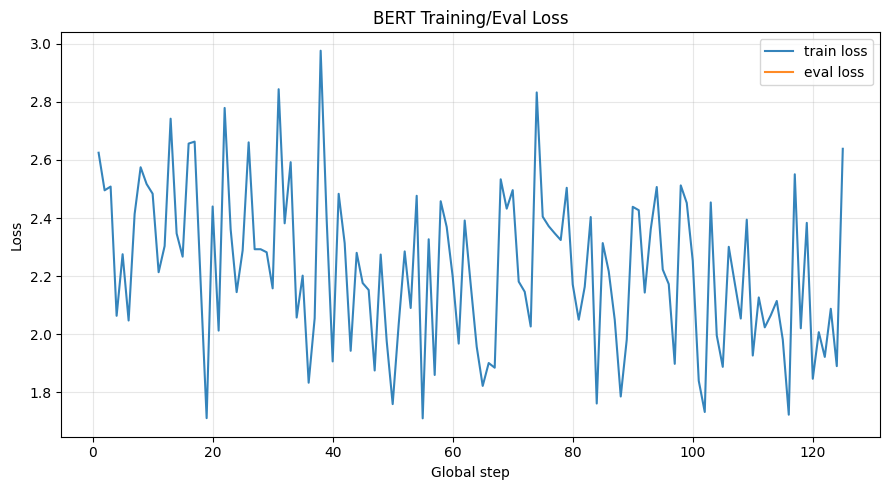

In [12]:
import matplotlib.pyplot as plt

# Extract logs collected during training
log_history = trainer_bert.state.log_history

# Training loss per logging step
train_points = [(e["step"], e["loss"]) for e in log_history if "loss" in e and "step" in e]
# Evaluation loss (if evaluation_strategy="steps")
eval_points  = [(e["step"], e["eval_loss"]) for e in log_history if "eval_loss" in e and "step" in e]

plt.figure(figsize=(9,5))
if train_points:
    steps, losses = zip(*train_points)
    plt.plot(steps, losses, label="train loss", alpha=0.9)
if eval_points:
    eval_steps, eval_losses = zip(*eval_points)
    plt.plot(eval_steps, eval_losses, label="eval loss", alpha=0.9)

plt.xlabel("Global step")
plt.ylabel("Loss")
plt.title("BERT Training/Eval Loss")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

#### Bert sample output

In [ ]:
# Generated by GPT-5 (medium reasoning) via windsurf 9/15/25
# Prompt: Can you generate a cell to calculate the pseudo-perplexity for the above code

# === BERT "summary" via iterative fill-mask + pseudo-perplexity demo ===
import torch
import re
from datasets import load_dataset
from typing import List

# Reuse existing bert_tokenizer, bert_model from your training cell if available.
# Otherwise, try to load your fine-tuned checkpoint, falling back to base.
try:
    if "bert_tokenizer" not in globals() or "bert_model" not in globals():
        from transformers import AutoTokenizer, AutoModelForMaskedLM
        bert_tokenizer = AutoTokenizer.from_pretrained("./bert-mlm")
        bert_model = AutoModelForMaskedLM.from_pretrained("./bert-mlm")
        print("Loaded fine-tuned BERT MLM from ./bert-mlm")
except Exception as e:
    print("Could not load ./bert-mlm; falling back to bert-base-uncased:", e)
    from transformers import AutoTokenizer, AutoModelForMaskedLM
    bert_model_name = "bert-base-uncased"
    bert_tokenizer = AutoTokenizer.from_pretrained(bert_model_name)
    bert_model = AutoModelForMaskedLM.from_pretrained(bert_model_name)

# Device
device = torch.device(
    "mps" if torch.backends.mps.is_available() else
    ("cuda" if torch.cuda.is_available() else "cpu")
)
bert_model.to(device)
bert_model.eval()

CLS_ID = bert_tokenizer.cls_token_id
SEP_ID = bert_tokenizer.sep_token_id
MASK_ID = bert_tokenizer.mask_token_id
SPECIAL_IDS = set(bert_tokenizer.all_special_ids + [MASK_ID])

def first_n_sentences(text: str, n: int = 3) -> str:
    sents = re.split(r'(?<=[.!?])\s+', text.strip())
    sents = [s for s in sents if s]
    return " ".join(sents[:n]).strip()

@torch.no_grad()
def bert_fill_mask_summary(article: str,
                           max_summary_tokens: int = 40,
                           min_summary_tokens: int = 12,
                           context_budget: int = 512,
                           topk_search: int = 20) -> str:
    """
    Approximate a summary by iteratively filling [MASK] tokens after 'Summary:'.
    This is illustrative only; BERT is not a generative model.
    """
    # Build a compact instruction prompt (add_special_tokens=False so we control [CLS]/[SEP])
    prompt_text = (
        "Summarize the following news article in 2-3 concise sentences: "
        + article.strip()
        + " Summary:"
    )

    # Compute how many tokens we can allocate to the prompt so that
    # [CLS] + prompt_ids + [MASK]*max_summary_tokens + [SEP] <= context_budget
    # - We reserve 2 for [CLS]/[SEP] and max_summary_tokens for masks
    max_prompt_tokens = max(1, context_budget - max_summary_tokens - 2)
    prompt_ids = bert_tokenizer.encode(
        prompt_text,
        add_special_tokens=False,
        truncation=True,
        max_length=max_prompt_tokens,
    )

    # Compose full input: [CLS] + prompt_ids + [MASK]*N + [SEP]
    input_ids: List[int] = [CLS_ID] + prompt_ids + [MASK_ID] * max_summary_tokens + [SEP_ID]
    attention_mask = [1] * len(input_ids)

    input_ids_t = torch.tensor([input_ids], dtype=torch.long, device=device)
    attn_mask_t = torch.tensor([attention_mask], dtype=torch.long, device=device)

    # Indices where summary tokens live
    start_idx = 1 + len(prompt_ids)
    end_idx = start_idx + max_summary_tokens

    # Iteratively fill masks left-to-right
    for pos in range(start_idx, end_idx):
        # Ensure the current position is [MASK]
        input_ids_t[0, pos] = MASK_ID

        outputs = bert_model(input_ids=input_ids_t, attention_mask=attn_mask_t)
        logits = outputs.logits[0, pos]  # (vocab_size,)

        # Choose top non-special token
        topk_scores, topk_ids = torch.topk(logits, k=topk_search)
        chosen_id = None
        for cand_id in topk_ids.tolist():
            if cand_id not in SPECIAL_IDS:
                chosen_id = cand_id
                break
        if chosen_id is None:
            chosen_id = int(torch.argmax(logits).item())

        input_ids_t[0, pos] = chosen_id

        # Early stop: if we generated a sentence terminator and have min tokens, we can stop
        if pos - start_idx + 1 >= min_summary_tokens:
            # Decode the current generated piece only and check sentence end
            gen_ids = input_ids_t[0, start_idx:pos + 1].tolist()
            gen_text = bert_tokenizer.decode(gen_ids, skip_special_tokens=True)
            if re.search(r'[.!?]\s*$', gen_text.strip()):
                break

    # Decode the generated summary span up to the first [SEP]
    full_ids = input_ids_t[0].tolist()
    # Find [SEP] after the summary start
    try:
        sep_after = full_ids.index(SEP_ID, start_idx)
    except ValueError:
        sep_after = end_idx
    gen_span = full_ids[start_idx:sep_after]
    summary = bert_tokenizer.decode(gen_span, skip_special_tokens=True)
    summary = first_n_sentences(summary, n=3)
    return summary if summary else "[Empty (BERT MLM fill-mask is limited)]"

@torch.no_grad()
def bert_pseudo_perplexity(text: str, max_len: int = 256) -> float:
    """
    Pseudo-perplexity for BERT:
    mask each token (one at a time), get the negative log prob of the original token,
    average over positions, then exponentiate. This is expensive; we truncate.
    """
    enc = bert_tokenizer(text, add_special_tokens=True, truncation=True, max_length=max_len, return_tensors="pt")
    input_ids = enc["input_ids"][0].to(device)
    attn_mask = enc["attention_mask"][0].to(device)

    nlls = []
    for i in range(1, input_ids.shape[0] - 1):  # skip [CLS] at 0 and last [SEP]
        orig_id = input_ids[i].item()
        if orig_id in SPECIAL_IDS:
            continue
        tmp_ids = input_ids.clone()
        tmp_ids[i] = MASK_ID
        outputs = bert_model(input_ids=tmp_ids.unsqueeze(0), attention_mask=attn_mask.unsqueeze(0))
        logits = outputs.logits[0, i]
        log_probs = torch.log_softmax(logits, dim=-1)
        nll = -log_probs[orig_id]
        nlls.append(nll.item())
    if not nlls:
        return float("nan")
    avg_nll = sum(nlls) / len(nlls)
    return float(torch.exp(torch.tensor(avg_nll)).item())

# --- Demo on 3 random CNN/DailyMail test examples ---
test_ds = load_dataset("cnn_dailymail", "3.0.0", split="test").select(range(0,3))

for i, ex in enumerate(test_ds):
    article = ex["article"]
    reference = ex["highlights"]

    gen = bert_fill_mask_summary(article, max_summary_tokens=80, min_summary_tokens=30)
    ppl = bert_pseudo_perplexity(article + " " + reference, max_len=256)

    print(f"\n=== BERT MLM Approximate Summary — Sample #{i+1} ===")
    print("Article (truncated):", article[:400].replace("\n", " "), "...")
    print("\nReference summary:")
    print(reference.strip())
    print("\nBERT (fill-mask) pseudo-summary:")
    print(gen)
    print(f"\nBERT pseudo-perplexity on article+summary (truncated to 256 tokens): {ppl:.3f}")
    print("=" * 80)


=== BERT MLM Approximate Summary — Sample #1 ===
Article (truncated): (CNN)The Palestinian Authority officially became the 123rd member of the International Criminal Court on Wednesday, a step that gives the court jurisdiction over alleged crimes in Palestinian territories. The formal accession was marked with a ceremony at The Hague, in the Netherlands, where the court is based. The Palestinians signed the ICC's founding Rome Statute in January, when they also acce ...

Reference summary:
Membership gives the ICC jurisdiction over alleged crimes committed in Palestinian territories since last June .
Israel and the United States opposed the move, which could open the door to war crimes investigations against Israelis .

BERT (fill-mask) pseudo-summary:
the icc. " the icc ' s first hearing on the icc ' s founding was a brief hearing on the icc. " the icc will be acting as a state party in the icc.

BERT pseudo-perplexity on article+summary (truncated to 256 tokens): 3.155

=== BERT MLM

#### BERT Summary Generation analysis

The Bert model is able to produce text that is based on the input text, however it is not able to generate this text in a coherent way. It is generally coherent for a few words at a time, but after this, it falls apart and is no longer coherent.

# T-5 Model

#### T-5 training

In [9]:
# From hotstart

from transformers import AutoTokenizer, AutoModelForSeq2SeqLM, DataCollatorForSeq2Seq, Trainer, TrainingArguments
from datasets import load_dataset
# Load the cnn_dailymail dataset (version 3.0.0)
dataset = load_dataset("cnn_dailymail", "3.0.0")

# For quick experimentation, take a small subset
train_size = 500
val_size = 100
small_train_dataset = dataset["train"].shuffle(seed=42).select(range(train_size))
small_val_dataset = dataset["validation"].shuffle(seed=42).select(range(val_size))
print("Dataset splits:", dataset.keys())
print("Example training record:", small_train_dataset[0])

# Load T5 tokenizer and model
t5_model_name = "t5-small"
t5_tokenizer = AutoTokenizer.from_pretrained(t5_model_name)

def preprocess_t5(examples):
    inputs = ["summarize: " + doc for doc in examples["article"]]
    model_inputs = t5_tokenizer(inputs, max_length=512, truncation=True)

    # Tokenize targets
    labels = t5_tokenizer(examples["highlights"], max_length=128, truncation=True)
    model_inputs["labels"] = labels["input_ids"]
    return model_inputs

train_t5 = small_train_dataset.map(preprocess_t5, batched=True, remove_columns=dataset["train"].column_names)
val_t5 = small_val_dataset.map(preprocess_t5, batched=True, remove_columns=dataset["validation"].column_names)

# Data collator for seq2seq tasks
data_collator_t5 = DataCollatorForSeq2Seq(tokenizer=t5_tokenizer, model=t5_model_name)

# Load T5 model
t5_model = AutoModelForSeq2SeqLM.from_pretrained(t5_model_name)

# Training arguments for T5
training_args_t5 = TrainingArguments(
    output_dir="./t5-summarization",
    eval_strategy="steps",
    eval_steps=100,
    logging_steps=1,
    per_device_train_batch_size=2,
    per_device_eval_batch_size=2,
    num_train_epochs=3,
    weight_decay=0.01,
    save_steps=500,
    save_total_limit=1,
    warmup_steps=50,
    gradient_accumulation_steps=4,
    fp16=torch.cuda.is_available(),
    report_to=[],
)

trainer_t5 = Trainer(
    model=t5_model,
    args=training_args_t5,
    train_dataset=train_t5,
    eval_dataset=val_t5,
    data_collator=data_collator_t5,
    tokenizer=t5_tokenizer,
)

# Uncomment the line below to train the T5 model
trainer_t5.train()

Dataset splits: dict_keys(['train', 'validation', 'test'])
Example training record: {'article': "By . Anthony Bond . PUBLISHED: . 07:03 EST, 2 March 2013 . | . UPDATED: . 08:07 EST, 2 March 2013 . Three members of the same family who died in a static caravan from carbon monoxide poisoning would have been unconscious 'within minutes', investigators said today. The bodies of married couple John and Audrey Cook were discovered alongside their daughter, Maureen, at the mobile home they shared on Tremarle Home Park in Camborne, west Cornwall. The inquests have now opened into the deaths last Saturday, with investigators saying the three died along with the family's pet dog, of carbon monoxide poisoning from a cooker. Tragic: The inquests have opened into the deaths of three members of the same family who were found in their static caravan last weekend. John and Audrey Cook are pictured . Awful: The family died following carbon monoxide poisoning at this caravan at the Tremarle Home Park in 

/var/folders/yr/p03j319114v61sg1cs61p6r80000gn/T/ipykernel_61549/1141433940.py:56: FutureWarning: `tokenizer` is deprecated and will be removed in version 5.0.0 for `Trainer.__init__`. Use `processing_class` instead.
  trainer_t5 = Trainer(
/Users/rkutyna/CascadeProjects/MSIT3103/MSIT3103-GenAI-assignments/.venv/lib/python3.13/site-packages/torch/utils/data/dataloader.py:684: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pinned memory won't be used.
  warnings.warn(warn_msg)


{'loss': 3.3412, 'grad_norm': 3.8099515438079834, 'learning_rate': 0.0, 'epoch': 0.016}
{'loss': 2.7268, 'grad_norm': 3.260061502456665, 'learning_rate': 1.0000000000000002e-06, 'epoch': 0.032}
{'loss': 2.0948, 'grad_norm': 1.9694290161132812, 'learning_rate': 2.0000000000000003e-06, 'epoch': 0.048}
{'loss': 2.936, 'grad_norm': 2.5897772312164307, 'learning_rate': 3e-06, 'epoch': 0.064}
{'loss': 2.416, 'grad_norm': 3.354149341583252, 'learning_rate': 4.000000000000001e-06, 'epoch': 0.08}
{'loss': 2.7718, 'grad_norm': 2.5957443714141846, 'learning_rate': 5e-06, 'epoch': 0.096}
{'loss': 2.065, 'grad_norm': 2.4424350261688232, 'learning_rate': 6e-06, 'epoch': 0.112}
{'loss': 3.0094, 'grad_norm': 3.606919288635254, 'learning_rate': 7.000000000000001e-06, 'epoch': 0.128}
{'loss': 3.0169, 'grad_norm': 2.505920171737671, 'learning_rate': 8.000000000000001e-06, 'epoch': 0.144}
{'loss': 2.5046, 'grad_norm': 2.4959652423858643, 'learning_rate': 9e-06, 'epoch': 0.16}
{'loss': 2.4602, 'grad_norm':

TrainOutput(global_step=189, training_loss=2.1795007873464516, metrics={'train_runtime': 134.6179, 'train_samples_per_second': 11.143, 'train_steps_per_second': 1.404, 'train_loss': 2.1795007873464516, 'epoch': 3.0})

[{'loss': 3.3412, 'grad_norm': 3.8099515438079834, 'learning_rate': 0.0, 'epoch': 0.016, 'step': 1}, {'loss': 2.7268, 'grad_norm': 3.260061502456665, 'learning_rate': 1.0000000000000002e-06, 'epoch': 0.032, 'step': 2}, {'loss': 2.0948, 'grad_norm': 1.9694290161132812, 'learning_rate': 2.0000000000000003e-06, 'epoch': 0.048, 'step': 3}, {'loss': 2.936, 'grad_norm': 2.5897772312164307, 'learning_rate': 3e-06, 'epoch': 0.064, 'step': 4}, {'loss': 2.416, 'grad_norm': 3.354149341583252, 'learning_rate': 4.000000000000001e-06, 'epoch': 0.08, 'step': 5}, {'loss': 2.7718, 'grad_norm': 2.5957443714141846, 'learning_rate': 5e-06, 'epoch': 0.096, 'step': 6}, {'loss': 2.065, 'grad_norm': 2.4424350261688232, 'learning_rate': 6e-06, 'epoch': 0.112, 'step': 7}, {'loss': 3.0094, 'grad_norm': 3.606919288635254, 'learning_rate': 7.000000000000001e-06, 'epoch': 0.128, 'step': 8}, {'loss': 3.0169, 'grad_norm': 2.505920171737671, 'learning_rate': 8.000000000000001e-06, 'epoch': 0.144, 'step': 9}, {'loss': 

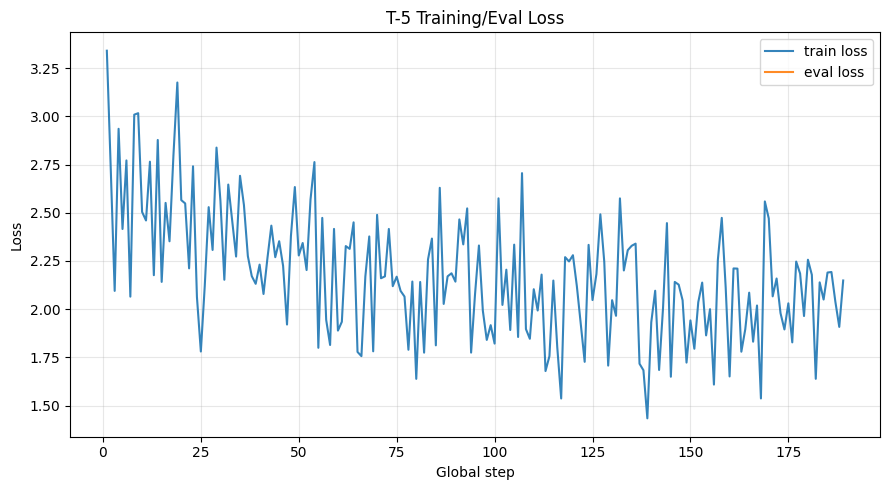

In [10]:
import matplotlib.pyplot as plt

# Extract logs collected during training
log_history = trainer_t5.state.log_history
print(log_history)

# Training loss per logging step
train_points = [(e["step"], e["loss"]) for e in log_history if "loss" in e and "step" in e]
# Evaluation loss (if evaluation_strategy="steps")
eval_points  = [(e["step"], e["eval_loss"]) for e in log_history if "eval_loss" in e and "step" in e]

plt.figure(figsize=(9,5))
if train_points:
    steps, losses = zip(*train_points)
    plt.plot(steps, losses, label="train loss", alpha=0.9)
if eval_points:
    eval_steps, eval_losses = zip(*eval_points)
    plt.plot(eval_steps, eval_losses, label="eval loss", alpha=0.9)

plt.xlabel("Global step")
plt.ylabel("Loss")
plt.title("T-5 Training/Eval Loss")
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

#### Example output of T-5 model

In [13]:
# Code generated by GPT-5 (medium reasoning) via Windsurf 9/15/25
# Prompt: Can you generate a cell to have the t-5 model generate 3 example summaries 
# based on the data set that is used to train it, although please use the test subset 
# rather than the train.@assignment_2.ipynb#X63sZmlsZQ%3D%3D#L1-66 Here is the code

# Generate 3 example summaries from the test split using the (fine-tuned or base) T5 model

import torch

# Ensure model is on the right device
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
t5_model.to(device)
t5_model.eval()

# Pick 3 random-ish examples from the test set
test_examples = dataset["test"].select(range(0,3))

with torch.no_grad():
    for i, ex in enumerate(test_examples):
        article_text = ex["article"]
        reference_summary = ex["highlights"]

        # Prepare input for T5 ("summarize:" prefix is required for T5)
        input_text = "summarize: " + article_text
        enc = t5_tokenizer(
            input_text,
            return_tensors="pt",
            truncation=True,
            max_length=512,
        )
        input_ids = enc["input_ids"].to(device)
        attention_mask = enc["attention_mask"].to(device)

        # Generate summary
        generated_ids = t5_model.generate(
            input_ids=input_ids,
            attention_mask=attention_mask,
            max_new_tokens=128,
            num_beams=4,
            early_stopping=True,
            length_penalty=1.0,
            no_repeat_ngram_size=3,
        )
        pred_summary = t5_tokenizer.decode(generated_ids[0], skip_special_tokens=True)

        # Print results (truncate article for readability)
        print(f"\n=== Example {i+1} ===")
        print("Article (truncated):")
        print(article_text[:600].replace("\n", " ") + ("..." if len(article_text) > 600 else ""))
        print("\nGenerated Summary:")
        print(pred_summary)
        print("\nReference Summary:")
        print(reference_summary)
        print("=" * 80)


=== Example 1 ===
Article (truncated):
(CNN)The Palestinian Authority officially became the 123rd member of the International Criminal Court on Wednesday, a step that gives the court jurisdiction over alleged crimes in Palestinian territories. The formal accession was marked with a ceremony at The Hague, in the Netherlands, where the court is based. The Palestinians signed the ICC's founding Rome Statute in January, when they also accepted its jurisdiction over alleged crimes committed "in the occupied Palestinian territory, including East Jerusalem, since June 13, 2014." Later that month, the ICC opened a preliminary examination i...

Generated Summary:
The Palestinian Authority officially became the 123rd member of the International Criminal Court on Wednesday. The formal accession was marked with a ceremony at The Hague, in the Netherlands, where the court is based. Israel and the United States opposed the Palestinians' efforts to join the body.

Reference Summary:
Membership gives

#### Analysis of T-5 generated article

The text generated by T-5 is much more coherent than with than the text generated by BERT. The text is coherent, formed into sentences, and does not repeat. It is also an actual summary as opposed to a continuation of the article. Because of this, it is by far the best of the models so far, and I imaging that it will score much higher on the rouge and perplexity compared to GPT-2 and Bert.

#### Evaluating the T-5 model

In [ ]:
# Generated by GPT-5 (medium reasoning) via Windsurf 9/15/25
# Prompt: Thanks! can you now write some code to compute the perplexity and rouge score 
# of the t-5 model? Please do it in a similar way to this code that does it for gpt-2: 
# @assignment_2.ipynb#X25sZmlsZQ%3D%3D#L1-42 

# Evaluate T5: compute perplexity and ROUGE (similar to the GPT-2 block)

import os
import torch
import evaluate

# Recommended on MPS to fall back to CPU for unsupported ops rather than erroring
os.environ["PYTORCH_ENABLE_MPS_FALLBACK"] = "1"

# Resolve device (prefer MPS on Apple Silicon)
device = torch.device(
    "mps" if torch.backends.mps.is_available() else
    ("cuda" if torch.cuda.is_available() else "cpu")
)
print(f"Using device: {device}")

# Ensure model is on the device and in float32 on MPS
t5_model.to(device=device, dtype=torch.float32)
t5_model.eval()

# Warm-up pass to force allocation on MPS (helps avoid "Placeholder storage" error)
if device.type == "mps":
    with torch.no_grad():
        _warm = t5_tokenizer("summarize: warmup", return_tensors="pt")
        _warm = {k: v.to(device) for k, v in _warm.items()}
        _ = t5_model.generate(**_warm, max_new_tokens=1)

# Reuse helpers if they exist; otherwise define them
try:
    compute_metrics_rouge
except NameError:
    evaluate_rouge = evaluate.load("rouge")
    def compute_metrics_rouge(preds, refs):
        result = evaluate_rouge.compute(predictions=preds, references=refs, use_stemmer=True)
        return {k: round(v * 100, 2) for k, v in result.items()}

try:
    compute_perplexity
except NameError:
    def compute_perplexity(eval_output):
        loss = eval_output["eval_loss"]
        return round(torch.exp(torch.tensor(loss)).item(), 3)

def evaluate_t5(model, tokenizer, dataset, lp=1.0, nr=1, num_samples=10, nb=1):
    model.eval()
    preds, refs = [], []

    # Get the real device from the model's parameters (robust and explicit)
    model_device = next(model.parameters()).device

    for example in dataset.select(range(num_samples)):
        prompt = "summarize: " + example["article"]
        enc = tokenizer(prompt, return_tensors="pt", truncation=True, max_length=512)
        # Move all tensors to the model device
        enc = {k: v.to(model_device) for k, v in enc.items()}
        with torch.no_grad():
            output_ids = model.generate(
                **enc,
                max_new_tokens=128,
                length_penalty=lp,
                no_repeat_ngram_size=nr,
                do_sample=False,
                num_beams=nb,
                early_stopping=True,
            )
        summary = tokenizer.decode(output_ids[0], skip_special_tokens=True)
        preds.append(summary)
        refs.append(example["highlights"])

    rouge_scores = compute_metrics_rouge(preds, refs)
    return rouge_scores

# Perplexity from evaluation loss (uses the eval_dataset configured in trainer_t5)
# Trainer handles device internally; no manual .to() needed here
t5_eval_results = trainer_t5.evaluate()
t5_perplexity = compute_perplexity(t5_eval_results)

# ROUGE on a small subset of the validation set (match GPT-2 example)
# To use the test split instead, replace small_val_dataset with:
# dataset["test"].shuffle(seed=42).select(range(10))
rouge_t5 = evaluate_t5(t5_model, t5_tokenizer, small_val_dataset, lp=1.0, nr=1, num_samples=10, nb=1)

print("T5 Perplexity:", t5_perplexity)
print("T5 ROUGE:", rouge_t5)

Using device: mps
{'eval_loss': 1.907762885093689, 'eval_runtime': 2.9784, 'eval_samples_per_second': 33.575, 'eval_steps_per_second': 16.787, 'epoch': 3.0}
T5 Perplexity: 6.738
T5 ROUGE: {'rouge1': np.float64(35.54), 'rouge2': np.float64(11.03), 'rougeL': np.float64(21.0), 'rougeLsum': np.float64(26.35)}


#### Fine tuning the T-5 Model:

Testing the number of beams

In [18]:
# Perplexity from evaluation loss (uses the eval_dataset configured in trainer_t5)
# Trainer handles device internally; no manual .to() needed here
t5_eval_results = trainer_t5.evaluate()
t5_perplexity = compute_perplexity(t5_eval_results)

print("T5 Perplexity:", t5_perplexity)

# ROUGE on a small subset of the validation set (match GPT-2 example)
# To use the test split instead, replace small_val_dataset with:
# dataset["test"].shuffle(seed=42).select(range(10))

for i in range(1, 10):
    print(" Number of beams:", i)
    rouge_t5 = evaluate_t5(t5_model, t5_tokenizer, small_val_dataset, lp=1.0, nr=1, num_samples=10, nb=i)
    print("T5 ROUGE:", rouge_t5)

/Users/rkutyna/CascadeProjects/MSIT3103/MSIT3103-GenAI-assignments/.venv/lib/python3.13/site-packages/torch/utils/data/dataloader.py:684: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pinned memory won't be used.
  warnings.warn(warn_msg)


{'eval_loss': 1.907762885093689, 'eval_runtime': 3.5226, 'eval_samples_per_second': 28.388, 'eval_steps_per_second': 14.194, 'epoch': 3.0}
T5 Perplexity: 6.738
 Number of beams: 1
T5 ROUGE: {'rouge1': np.float64(35.54), 'rouge2': np.float64(11.03), 'rougeL': np.float64(21.0), 'rougeLsum': np.float64(26.35)}
 Number of beams: 2
T5 ROUGE: {'rouge1': np.float64(32.91), 'rouge2': np.float64(10.22), 'rougeL': np.float64(20.63), 'rougeLsum': np.float64(25.29)}
 Number of beams: 3
T5 ROUGE: {'rouge1': np.float64(36.52), 'rouge2': np.float64(10.77), 'rougeL': np.float64(22.71), 'rougeLsum': np.float64(28.78)}
 Number of beams: 4
T5 ROUGE: {'rouge1': np.float64(37.33), 'rouge2': np.float64(11.38), 'rougeL': np.float64(22.67), 'rougeLsum': np.float64(29.88)}
 Number of beams: 5
T5 ROUGE: {'rouge1': np.float64(35.66), 'rouge2': np.float64(10.7), 'rougeL': np.float64(22.8), 'rougeLsum': np.float64(28.8)}
 Number of beams: 6
T5 ROUGE: {'rouge1': np.float64(36.68), 'rouge2': np.float64(12.33), 'roug

Impact of the number of beams:



Evaluating effect of length penalty:

In [20]:
# Perplexity from evaluation loss (uses the eval_dataset configured in trainer_t5)
# Trainer handles device internally; no manual .to() needed here
t5_eval_results = trainer_t5.evaluate()
t5_perplexity = compute_perplexity(t5_eval_results)

print("T5 Perplexity:", t5_perplexity)

# ROUGE on a small subset of the validation set (match GPT-2 example)
# To use the test split instead, replace small_val_dataset with:
# dataset["test"].shuffle(seed=42).select(range(10))

for i in range(10, 15):
    print("Length Penalty:", i/10)
    rouge_t5 = evaluate_t5(t5_model, t5_tokenizer, small_val_dataset, lp=i/10, nr=1, num_samples=10, nb=2)
    print("T5 ROUGE:", rouge_t5)

{'eval_loss': 1.907762885093689, 'eval_runtime': 3.3467, 'eval_samples_per_second': 29.88, 'eval_steps_per_second': 14.94, 'epoch': 3.0}
T5 Perplexity: 6.738
Length Penalty: 1.0
T5 ROUGE: {'rouge1': np.float64(32.91), 'rouge2': np.float64(10.22), 'rougeL': np.float64(20.63), 'rougeLsum': np.float64(25.29)}
Length Penalty: 1.1
T5 ROUGE: {'rouge1': np.float64(32.82), 'rouge2': np.float64(10.22), 'rougeL': np.float64(20.59), 'rougeLsum': np.float64(25.24)}
Length Penalty: 1.2
T5 ROUGE: {'rouge1': np.float64(32.82), 'rouge2': np.float64(10.22), 'rougeL': np.float64(20.59), 'rougeLsum': np.float64(25.24)}
Length Penalty: 1.3
T5 ROUGE: {'rouge1': np.float64(32.82), 'rouge2': np.float64(10.22), 'rougeL': np.float64(20.59), 'rougeLsum': np.float64(25.24)}
Length Penalty: 1.4
T5 ROUGE: {'rouge1': np.float64(32.82), 'rouge2': np.float64(10.22), 'rougeL': np.float64(20.59), 'rougeLsum': np.float64(25.24)}


Impact of Length penalty:

Similar to GPT-2, this performs slightly worse with the length penalty increased. It also stops affecting the performance after 1.1. This is likely because of the relatively short max_new_tokens limit that prevents the model from reaching the ending token. This might also be related to the number of beams being set to 2, so there will only ever be two choices for the beams to choose from.

Evaluating no repeat ngram:

In [21]:
# Perplexity from evaluation loss (uses the eval_dataset configured in trainer_t5)
# Trainer handles device internally; no manual .to() needed here
t5_eval_results = trainer_t5.evaluate()
t5_perplexity = compute_perplexity(t5_eval_results)

print("T5 Perplexity:", t5_perplexity)

# ROUGE on a small subset of the validation set (match GPT-2 example)
# To use the test split instead, replace small_val_dataset with:
# dataset["test"].shuffle(seed=42).select(range(10))

for i in range(1, 5):
    print("no repeat ngram:", i)
    rouge_t5 = evaluate_t5(t5_model, t5_tokenizer, small_val_dataset, lp=1, nr=i, num_samples=10, nb=2)
    print("T5 ROUGE:", rouge_t5)

/Users/rkutyna/CascadeProjects/MSIT3103/MSIT3103-GenAI-assignments/.venv/lib/python3.13/site-packages/torch/utils/data/dataloader.py:684: UserWarning: 'pin_memory' argument is set as true but not supported on MPS now, then device pinned memory won't be used.
  warnings.warn(warn_msg)


{'eval_loss': 1.907762885093689, 'eval_runtime': 3.7239, 'eval_samples_per_second': 26.854, 'eval_steps_per_second': 13.427, 'epoch': 3.0}
T5 Perplexity: 6.738
no repeat ngram: 1
T5 ROUGE: {'rouge1': np.float64(32.91), 'rouge2': np.float64(10.22), 'rougeL': np.float64(20.63), 'rougeLsum': np.float64(25.29)}
no repeat ngram: 2
T5 ROUGE: {'rouge1': np.float64(37.59), 'rouge2': np.float64(13.44), 'rougeL': np.float64(23.64), 'rougeLsum': np.float64(29.15)}
no repeat ngram: 3
T5 ROUGE: {'rouge1': np.float64(36.88), 'rouge2': np.float64(12.99), 'rougeL': np.float64(23.2), 'rougeLsum': np.float64(29.26)}
no repeat ngram: 4
T5 ROUGE: {'rouge1': np.float64(36.33), 'rouge2': np.float64(12.46), 'rougeL': np.float64(23.42), 'rougeLsum': np.float64(29.07)}


Impact of no repeat ngram:

It seems that the best value for the no repeat ngram is 2, as this is the peak for most of the rouge metrics. It is clearly better than an ngram of 1. After 2, it declines in some metrics, so 2 is clearly the peak. 

# Conclusion

The T-5 model wins in the summarization task by a clear margin. It composed the most cohesive summaries that read like sentences that made sense together. It didn't necessarily capture the essence of the article, but it did much better than the other models. It was also the easiest to fine tune and seemed to be faster than GPT-2. The BERT model struggled significantly and was only able to string a few cohesive words together. However, given that this is not what it is built for, it did impressively. 